# Production 2D FEP Subtraction — Clean Rebuild
### SSA — Diamond I11 Beamline

**This replaces the exploratory `Production_Subtraction.ipynb`** built during live debugging. That version proved the method; this one is the reusable tool, per `FEP_Subtraction_Project_Plan.docx` Section 9.

**Confirmed fixed conditions (do not change per crystal system):** 100mm distance, Swish technique, radially-binned scale fitting as the default correction method (a single global scale factor was proven insufficient — see Trial 1 and this pipeline's own validation history).

**Parameterised per crystal system (change these, nothing else, for a new system):** `CRYSTAL_SAMPLE_CODE` and `BACKGROUND_SAMPLE_CODES` in Step 0.

**What this notebook does NOT assume:** which background wins, or what QC thresholds are appropriate — both are re-validated fresh in Step 5 for whatever crystal system is configured, never carried over from a previous system.

---
**Run cells one at a time, top to bottom.**

---
## Step 0 — Paths, geometry, and per-system parameters

In [1]:
import os, glob
import numpy as np
import pandas as pd
from scipy import ndimage

# ══════════════════════════════════════════════════════════════
# PATHS — confirm/update before running
# ══════════════════════════════════════════════════════════════

MODULE_DIR   = r"C:/Users/ezxsa27/I11_PXRD_SSA/I11_PXRD_processing_scripts/FEP_Subtraction/"
import sys
sys.path.insert(0, MODULE_DIR)

RAW_ROOT     = r"E:/static/raw/raw_D1+2"
OUTPUT_DIR   = r"E:/static/Corrected_2D/Production_100mm_Swish/"
TRACKER_PATH = r"C:/Users/ezxsa27/OneDrive - The University of Nottingham/Nottingham/Year 3 (June 26 -)/Static Trials/I11_Static_Trials_Tracker_CLEAN.xlsx"

PONI_100MM = r"E:/static/raw/Calib/Calib_100.poni"
MASK_100MM_BASE = r"E:/static/raw/Calib/Calib_100_mask.npy"   # original mask, BEFORE artifact scan

# ══════════════════════════════════════════════════════════════
# PER-CRYSTAL-SYSTEM PARAMETERS — change ONLY these for a new system
# ══════════════════════════════════════════════════════════════
DISTANCE_MM          = 100
EXPOSURE_CODE         = "Swish"
CRYSTAL_SAMPLE_CODE   = "Gly_AS_tri"
BACKGROUND_SAMPLE_CODES = ["Water_tri", "EtOH_tri"]   # candidates to validate, not assumed winners

os.makedirs(OUTPUT_DIR, exist_ok=True)

tracker = pd.read_excel(TRACKER_PATH, sheet_name="Condition Tracker", header=6)
tracker.columns = [str(c).strip() for c in tracker.columns]
tracker["Sample code"]   = tracker["Sample code"].astype(str).str.strip()
tracker["Exposure code"] = tracker["Exposure code"].astype(str).str.strip()
tracker["Data logged?"]  = tracker["Data logged?"].astype(str).str.strip().str.upper()

tracker_clean = tracker[
    (tracker["Data logged?"] == "Y") &
    (tracker["Exclude?"].isna())
]

def collection_numbers_for(sample_code, distance=DISTANCE_MM, exposure_code=EXPOSURE_CODE):
    sub = tracker_clean[
        (tracker_clean["Sample code"] == sample_code) &
        (tracker_clean["Distance (mm)"] == distance)
    ]
    if exposure_code is not None:
        sub = sub[sub["Exposure code"] == exposure_code]
    return sub["Collection #(s)"].dropna().astype(int).astype(str).tolist()

def extract_number(fp):
    stem = os.path.splitext(os.path.basename(fp))[0]
    for part in reversed(stem.replace("-", "_").split("_")):
        if part.isdigit():
            return part
    return ""

all_raw_files = sorted(glob.glob(os.path.join(RAW_ROOT, "*.nxs")))
all_numbers = {f: extract_number(f) for f in all_raw_files}

def files_for_numbers(numbers):
    wanted = set(numbers)
    return sorted([f for f, n in all_numbers.items() if n in wanted])

CRYSTAL_FILES = files_for_numbers(collection_numbers_for(CRYSTAL_SAMPLE_CODE))
BACKGROUND_FILES = {
    code: files_for_numbers(collection_numbers_for(code))
    for code in BACKGROUND_SAMPLE_CODES
}

print(f"Raw files found: {len(all_raw_files)}")
print(f"{CRYSTAL_SAMPLE_CODE} @ {DISTANCE_MM}mm/{EXPOSURE_CODE}: {len(CRYSTAL_FILES)} files")
for code, files in BACKGROUND_FILES.items():
    print(f"{code} @ {DISTANCE_MM}mm/{EXPOSURE_CODE}: {len(files)} files")

Raw files found: 199
Gly_AS_tri @ 100mm/Swish: 4 files
Water_tri @ 100mm/Swish: 4 files
EtOH_tri @ 100mm/Swish: 4 files


In [3]:
from fep_subtraction_2d_i11 import (
    beam_center_px_from_poni,
    FrameMetricConfig,
    evaluate_frame_with_status,
    classify_dataset,
    _load_pixium_frame,
    _mad_sigma,
)

cy, cx = beam_center_px_from_poni(PONI_100MM)
mask_base = np.load(MASK_100MM_BASE)
print(f"Geometry: beam centre row={cy:.2f} col={cx:.2f} ({mask_base.shape})")

cfg_probe = FrameMetricConfig(beam_center_px=(cy, cx), detect_fep_ring=True)
print("✅ Geometry loaded. Ready for Step 1.")

Geometry: beam centre row=1442.65 col=1441.74 ((2881, 2880))
✅ Geometry loaded. Ready for Step 1.


---
## Step 1 — FEP ring radius

Auto-detected fresh for this geometry, not assumed from a different distance/session.

In [4]:
probe_fp = list(BACKGROUND_FILES.values())[0][0] if any(BACKGROUND_FILES.values()) else CRYSTAL_FILES[0]
metrics, status = evaluate_frame_with_status(probe_fp, mask=mask_base, config=cfg_probe)
FEP_RING_R = status.fep_ring_r
print(f"Status: {status.status}")
print(f"FEP ring radius: {FEP_RING_R}px")

cfg = FrameMetricConfig(beam_center_px=(cy, cx), detect_fep_ring=False, fixed_fep_ring_r=FEP_RING_R)

Status: ok
FEP ring radius: 223px


---
## Step 2 — Fixed-pixel artifact detection (sensor property, not sample-dependent)

Scans EVERY available crystal-free background condition for pixels that are consistent outliers in ALL of them simultaneously — these cannot be genuine diffraction (which would only appear in crystal-containing frames), so they're almost certainly hot/dead detector pixels. Run once per geometry; result is reusable for any crystal system at this same distance.

In [5]:
def load_averaged(filepaths):
    frames = []
    for fp in filepaths:
        f = _load_pixium_frame(fp)
        if f.ndim == 3:
            f = f.mean(axis=0)
        frames.append(f)
    return np.mean(frames, axis=0)

def residual_map(arr, cy, cx):
    rows, cols = arr.shape
    y_idx, x_idx = np.ogrid[:rows, :cols]
    r_map = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)
    r_max = int(r_map.max())
    radial_sum = np.bincount(r_map.ravel(), weights=arr.ravel(), minlength=r_max + 1)
    radial_cnt = np.bincount(r_map.ravel(), minlength=r_max + 1)
    with np.errstate(invalid="ignore", divide="ignore"):
        radial_mean = np.where(radial_cnt > 0, radial_sum / radial_cnt, 0.0)
    return arr - radial_mean[r_map]

valid_mask_base = ~mask_base.astype(bool)
condition_averages = {code: load_averaged(files) for code, files in BACKGROUND_FILES.items() if files}
residuals = {code: residual_map(avg, cy, cx) for code, avg in condition_averages.items()}
sigmas = {code: _mad_sigma(res[valid_mask_base]) for code, res in residuals.items()}

artifact_mask = np.ones_like(mask_base, dtype=bool)
for code, res in residuals.items():
    artifact_mask &= (res > 8 * sigmas[code])
artifact_mask &= valid_mask_base

n_artifacts = int(artifact_mask.sum())
print(f"Suspected fixed-pixel artifacts (outlier in ALL {len(condition_averages)} conditions): {n_artifacts}")

mask = mask_base.copy()
mask[artifact_mask] = True
MASK_PATH_FINAL = os.path.join(OUTPUT_DIR, f"mask_{DISTANCE_MM}mm_artifacts_added.npy")
np.save(MASK_PATH_FINAL, mask)
print(f"Total masked pixels: {mask.sum()} (was {mask_base.sum()})")
print(f"Saved: {MASK_PATH_FINAL}")

valid_mask = ~mask.astype(bool)

Suspected fixed-pixel artifacts (outlier in ALL 2 conditions): 9612
Total masked pixels: 64310 (was 54698)
Saved: E:/static/Corrected_2D/Production_100mm_Swish/mask_100mm_artifacts_added.npy


---
## Step 3 — Build background candidates

Generic over `BACKGROUND_SAMPLE_CODES` — works unchanged for any crystal system's own trisegment conditions.

In [6]:
def average_frames(filepaths):
    stack = []
    for fp in filepaths:
        frame = _load_pixium_frame(fp)
        if frame.ndim == 3:
            frame = frame.mean(axis=0)
        stack.append(frame.astype(np.float64))
    return np.mean(stack, axis=0)

backgrounds = {}
for code, files in BACKGROUND_FILES.items():
    if not files:
        print(f"⚠️  No files for {code} — skipping")
        continue
    backgrounds[code] = average_frames(files)
    print(f"{code}: {len(files)} frames averaged (noise / \u221an = {1/np.sqrt(len(files)):.3f})")

print(f"\n✅ {len(backgrounds)} background candidate(s) built.")

Water_tri: 4 frames averaged (noise / √n = 0.500)
EtOH_tri: 4 frames averaged (noise / √n = 0.500)

✅ 2 background candidate(s) built.


---
## Step 4 — Classify crystal-sample frames

Identifies confirmed crystal-positive frames from `CRYSTAL_SAMPLE_CODE` — the set the background candidates will be validated against, and the set the production pass runs on.

In [7]:
csv_path = os.path.join(OUTPUT_DIR, f"{CRYSTAL_SAMPLE_CODE}_{DISTANCE_MM}mm_classification.csv")

crystal_metrics = classify_dataset(CRYSTAL_FILES, mask=mask, config=cfg, csv_output=csv_path)
crystal_frames = [m for m in crystal_metrics if m.auto_class == "crystal"]

print(f"\n{len(crystal_frames)} confirmed crystal frame(s) out of {len(crystal_metrics)} total:")
for m in crystal_frames:
    print(f"  {os.path.basename(m.filepath)}  score={m.crystal_score:.3f}")


────────────────────────────────────────────────────────────────
  Dataset classification  (4 frames from 4 files)
────────────────────────────────────────────────────────────────
  crystal         4 frames  ████████████████████████████████████████
  solution        0 frames  
  gas             0 frames  
  uncertain       0 frames  
────────────────────────────────────────────────────────────────

  Top crystal candidates:
    score=1.000  i11-1-145413.nxs  frame=0
    score=1.000  i11-1-145414.nxs  frame=0
    score=1.000  i11-1-145415.nxs  frame=0
    score=1.000  i11-1-145416.nxs  frame=0

  ML training CSV: E:/static/Corrected_2D/Production_100mm_Swish/Gly_AS_tri_100mm_classification.csv


4 confirmed crystal frame(s) out of 4 total:
  i11-1-145413.nxs  score=1.000
  i11-1-145414.nxs  score=1.000
  i11-1-145415.nxs  score=1.000
  i11-1-145416.nxs  score=1.000


---
## Step 5 — Background validation (radially-binned, both diffuse AND ring regions)

**Default correction method: radially-binned scale fitting**, not a single global scale — proven necessary, since a global scale reliably satisfies the diffuse region (dominated by pixel count) while leaving the FEP ring itself under-subtracted, invisibly to a diffuse-only check.

Every background candidate is checked against EVERY confirmed crystal frame, on BOTH the diffuse region and the ring region — not assumed from a previous crystal system or a single test frame.

In [8]:
def radial_bestfit_correct(raw, bg, valid_mask, r_map, bin_width=40):
    """Fit an independent best-fit scale per radial annulus. Returns
    the corrected frame AND the per-bin scale map, so the ring bin's
    actual fitted scale can be inspected/audited."""
    r_max = int(r_map.max())
    bins = np.arange(0, r_max + bin_width, bin_width)
    corrected = raw.copy()
    bin_scales = {}
    for lo, hi in zip(bins[:-1], bins[1:]):
        bin_mask = (r_map >= lo) & (r_map < hi) & valid_mask
        if bin_mask.sum() < 50:
            continue
        r_vals, b_vals = raw[bin_mask], bg[bin_mask]
        denom = np.sum(b_vals * b_vals)
        s = float(np.sum(r_vals * b_vals) / denom) if denom > 0 else 1.0
        corrected[bin_mask] = raw[bin_mask] - s * bg[bin_mask]
        bin_scales[(lo, hi)] = s
    return corrected, bin_scales

def bias_check(corrected, region_mask):
    vals = corrected[region_mask]
    med = np.median(vals)
    sigma = _mad_sigma(vals)
    return med / sigma if sigma > 0 else float("nan")

rows, cols = mask.shape
y_idx, x_idx = np.ogrid[:rows, :cols]
r_map_full = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)
diffuse_mask = (r_map_full >= 400) & (r_map_full <= 1200) & valid_mask
ring_mask = (r_map_full >= FEP_RING_R - 15) & (r_map_full <= FEP_RING_R + 15) & valid_mask

validation_results = []
for m in crystal_frames:
    raw = _load_pixium_frame(m.filepath, m.frame_index)
    if raw.ndim == 3:
        raw = raw[m.frame_index]
    for bg_name, bg_array in backgrounds.items():
        corrected, bin_scales = radial_bestfit_correct(raw, bg_array, valid_mask, r_map_full)
        diffuse_bias = bias_check(corrected, diffuse_mask)
        ring_bias = bias_check(corrected, ring_mask)
        validation_results.append({
            "file": os.path.basename(m.filepath), "background": bg_name,
            "diffuse_bias": diffuse_bias, "ring_bias": ring_bias,
        })

df_validation = pd.DataFrame(validation_results)
summary_validation = df_validation.groupby("background")[["diffuse_bias", "ring_bias"]].agg(["mean", "std"])
print(summary_validation)

print("\nPer-frame detail:")
print(df_validation.to_string(index=False))

           diffuse_bias           ring_bias          
                   mean       std      mean       std
background                                           
EtOH_tri       0.035528  0.011881 -0.099307  0.044688
Water_tri      0.010095  0.014827  0.297611  0.198914

Per-frame detail:
            file background  diffuse_bias  ring_bias
i11-1-145413.nxs  Water_tri      0.002739   0.086055
i11-1-145413.nxs   EtOH_tri      0.030888  -0.119088
i11-1-145414.nxs  Water_tri      0.032122   0.336298
i11-1-145414.nxs   EtOH_tri      0.053012  -0.032765
i11-1-145415.nxs  Water_tri      0.000250   0.214477
i11-1-145415.nxs   EtOH_tri      0.026483  -0.116413
i11-1-145416.nxs  Water_tri      0.005270   0.553613
i11-1-145416.nxs   EtOH_tri      0.031730  -0.128961


---
## Step 5b — Pick the winning background

Based on Step 5's output — update `WINNING_BACKGROUND` to whichever candidate shows the smallest mean |bias| on BOTH diffuse and ring regions across all confirmed frames. Not assumed from a different crystal system.

In [9]:
# ══════════════════════════════════════════════════════════════
# Set based on Step 5's printed summary — do not carry over from
# a different crystal system without re-checking.
# ══════════════════════════════════════════════════════════════
WINNING_BACKGROUND = "Water_tri"   # <-- update based on Step 5 output

print(f"Using background: {WINNING_BACKGROUND}")
winning_bg_array = backgrounds[WINNING_BACKGROUND]

Using background: Water_tri


---
## Step 5c — Secondary FEP polymer scattering feature (radius-localised)

**Observation:** `radial_bestfit_correct`'s per-annulus fitted scale shows a
pronounced trough (~0.72 vs. a smooth ~0.80–0.95 elsewhere) just beyond the
main FEP ring. After radially-binned subtraction, a systematic ring-shaped
residual survived spot-detection thresholding in that region — visible as a
near-complete ring in the Step 6 spots-only panel, not genuine sparse
diffraction.

**Diagnosis path (in order, each ruled out before the next):**
1. Bin-fit discontinuity from independent per-annulus fitting — ruled out:
   the swing is smooth across radius, not jagged at bin boundaries.
2. Glycine Bragg-ring contamination of the fit — ruled out: the raw radial
   profile has no local intensity feature at the trough radius that a
   diffraction ring would produce (it's the smooth tail of the FEP peak).
3. Radial misalignment between raw and background (beam-centre drift) —
   ruled out: raw vs. background overlay shows no horizontal offset anywhere.
4. Confirmed cause: a secondary, weaker FEP polymer scattering feature,
   present in BOTH independently-collected background candidates (Water_tri
   and EtOH_tri), but attenuated differently in the glycine-solution crystal
   frame — consistent with the differential-attenuation mechanism already
   established for FEP_empty (see Background_Comparison_Report /
   Trial_1_Report.docx).

**Locating the exclusion band — two attempts:**

*Attempt 1 (superseded, kept for record):* used where the fitted scale
profile deviated from its baseline (>5σ MAD) beyond the main ring, giving
r=330–710px. This measured a real effect (the background mismatch) but at
the wrong location — rerunning Step 6 with it still showed a near-complete
residual ring in the spots-only panel. A radius histogram of the actually-
surviving spot pixels showed the true residual sits at r≈150–260px, mostly
*inside* `ring_mask`'s previous lower edge — the scale-deviation method,
using 40px-wide bins starting the search well beyond the ring, was too
coarse to catch a discontinuity that sharp and that close to the ring itself.

*Attempt 2 (adopted):* empirical, pooled across all confirmed crystal
frames — measure what fraction of each radial annulus is flagged as
"spot" at the standard 5σ threshold; a genuinely sparse Bragg spot
population occupies a tiny fraction of any annulus, while a systematic
subtraction residual occupies a much larger fraction. The contiguous
high-occupancy region anchored at `FEP_RING_R` is taken as the true
exclusion band, found at r=158–288px — confirmed visually in Step 6: the
residual ring is gone from all four frames, leaving only sparse, scattered
points scaling sensibly with each frame's known diffraction strength.

**Conclusion:** this is a genuine, radius-localised background mismatch, not
a fitting bug. `radial_bestfit_correct` is correctly reporting it. Smoothing
or outlier-clipping the fit would incorrectly suppress real information.
Handled instead as a known exclusion band for spot-detection QC (Step 6).
`known_fep_exclusion` now covers the full footprint (ring + shoulder) on its
own and is used standalone for spot counting/display in Step 6.
`ring_mask` itself is unchanged and still used only for the Step 5/6
`bias_check` QC statistic, a separate purpose from spot exclusion.

**Caveat 1:** does not change the Water_tri vs EtOH_tri background choice —
present equally in both, so it's a shared limitation of any liquid-filled
background candidate tested so far, not a discriminator between them.

**Caveat 2:** the occupancy method cannot, by construction, distinguish
"systematic FEP residual ring" from "a genuine, fully-populated glycine
Debye-Scherrer ring" — both present as high annulus occupancy. Worth
checking against expected glycine 2θ reflection positions before reusing
this band on a new crystal system; a weaker/sparser diffractor than glycine
may need this re-derived rather than reused, since a real ring there could
otherwise be silently excluded as if it were FEP.

**Caught by:** the spot-visualisation panel (Step 6c), not by `bias_check`'s
aggregate ring statistic — a global median/MAD over the whole ring annulus
averages a locally-high region against a locally-low one and can still read
as PASS. Worth noting for CBZ beamtime, where there is no ground truth to
catch this kind of thing independently.

*Diagnostic cells below are kept as run, with outputs, as part of the
calibration record for the Water_tri/EtOH_tri background choice — not
discarded scratch work. Rerun this section if `CRYSTAL_SAMPLE_CODE` or
`WINNING_BACKGROUND` change.*

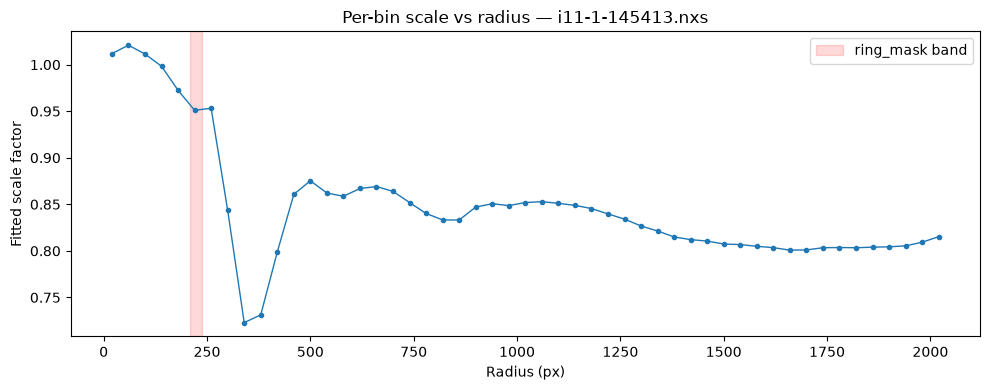

In [11]:
import matplotlib.pyplot as plt
# Diagnostic 1 — fitted scale vs radius for one confirmed crystal frame.
# A smooth, large-amplitude swing (not jagged bin-to-bin noise) rules out
# plain per-annulus fit discontinuity as the explanation.
m = crystal_frames[0]
raw = _load_pixium_frame(m.filepath, m.frame_index)
if raw.ndim == 3:
    raw = raw[m.frame_index]

_, bin_scales = radial_bestfit_correct(raw, winning_bg_array, valid_mask, r_map_full)
radii = [(lo + hi) / 2 for lo, hi in bin_scales]
scales = list(bin_scales.values())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(radii, scales, marker="o", ms=3, lw=1)
ax.axvspan(FEP_RING_R - 15, FEP_RING_R + 15, alpha=0.15, color="red", label="ring_mask band")
ax.set_xlabel("Radius (px)")
ax.set_ylabel("Fitted scale factor")
ax.set_title(f"Per-bin scale vs radius — {os.path.basename(m.filepath)}")
ax.legend()
plt.tight_layout()
plt.show()

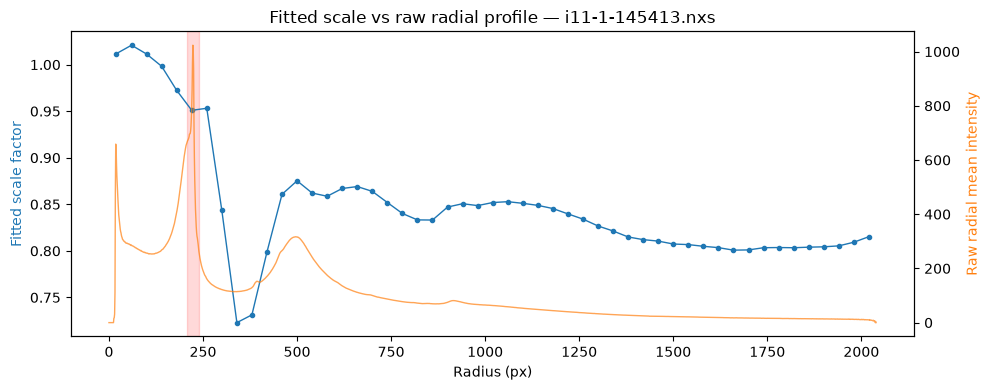

In [12]:
# Diagnostic 2 — overlay the raw radial profile on the same axes (twin y).
# Confirms the trough sits on the descending shoulder of the main FEP peak,
# not on a separate, unexplained feature.
radial_sum = np.bincount(r_map_full[valid_mask].ravel(), weights=raw[valid_mask].ravel(),
                          minlength=int(r_map_full.max()) + 1)
radial_cnt = np.bincount(r_map_full[valid_mask].ravel(), minlength=int(r_map_full.max()) + 1)
with np.errstate(invalid="ignore", divide="ignore"):
    raw_radial_mean = np.where(radial_cnt > 0, radial_sum / radial_cnt, 0.0)

bg_radial_sum = np.bincount(r_map_full[valid_mask].ravel(), weights=winning_bg_array[valid_mask].ravel(),
                             minlength=int(r_map_full.max()) + 1)
bg_radial_cnt = np.bincount(r_map_full[valid_mask].ravel(), minlength=int(r_map_full.max()) + 1)
with np.errstate(invalid="ignore", divide="ignore"):
    bg_radial_mean = np.where(bg_radial_cnt > 0, bg_radial_sum / bg_radial_cnt, 0.0)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(radii, scales, marker="o", ms=3, lw=1, color="tab:blue")
ax1.set_xlabel("Radius (px)")
ax1.set_ylabel("Fitted scale factor", color="tab:blue")
ax1.axvspan(FEP_RING_R - 15, FEP_RING_R + 15, alpha=0.15, color="red", label="ring_mask band")

ax2 = ax1.twinx()
ax2.plot(raw_radial_mean[:2100], lw=1, color="tab:orange", alpha=0.7)
ax2.set_ylabel("Raw radial mean intensity", color="tab:orange")
ax1.set_title(f"Fitted scale vs raw radial profile — {os.path.basename(m.filepath)}")
plt.tight_layout()
plt.show()

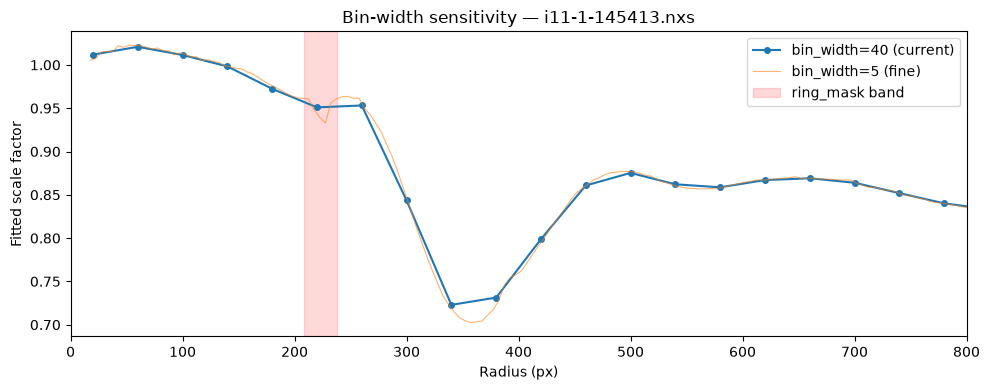

In [13]:
# Diagnostic 3 — bin-width sensitivity. If the swing is a coarse-binning
# artefact it should largely smooth out at fine bin_width; if it's a genuine
# radial background mismatch it should persist (just noisier).
_, bin_scales_fine = radial_bestfit_correct(raw, winning_bg_array, valid_mask, r_map_full, bin_width=5)
radii_fine = [(lo + hi) / 2 for lo, hi in bin_scales_fine]
scales_fine = list(bin_scales_fine.values())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(radii, scales, marker="o", ms=4, label="bin_width=40 (current)")
ax.plot(radii_fine, scales_fine, lw=0.8, alpha=0.6, label="bin_width=5 (fine)")
ax.axvspan(FEP_RING_R - 15, FEP_RING_R + 15, alpha=0.15, color="red", label="ring_mask band")
ax.set_xlim(0, 800)
ax.set_xlabel("Radius (px)")
ax.set_ylabel("Fitted scale factor")
ax.set_title(f"Bin-width sensitivity — {os.path.basename(m.filepath)}")
ax.legend()
plt.tight_layout()
plt.show()

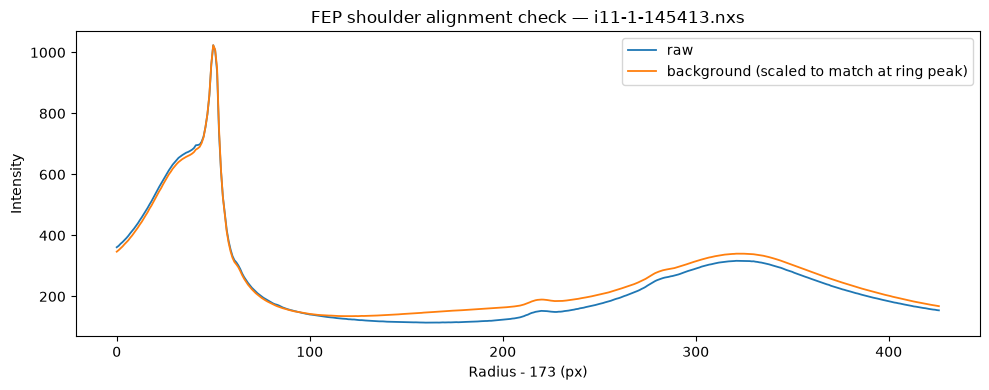

In [14]:
# Diagnostic 4 — shoulder alignment check. Overlay raw vs background radial
# profiles (background scaled to match raw at the ring peak) over the FEP
# shoulder region, to check for a radial offset vs. a shape difference.
lo, hi = FEP_RING_R - 50, 600
level_match = raw_radial_mean[FEP_RING_R] / bg_radial_mean[FEP_RING_R]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_radial_mean[lo:hi], label="raw", lw=1.3)
ax.plot(bg_radial_mean[lo:hi] * level_match, label="background (scaled to match at ring peak)", lw=1.3)
ax.set_xlabel(f"Radius - {lo} (px)")
ax.set_ylabel("Intensity")
ax.set_title(f"FEP shoulder alignment check — {os.path.basename(m.filepath)}")
ax.legend()
plt.tight_layout()
plt.show()

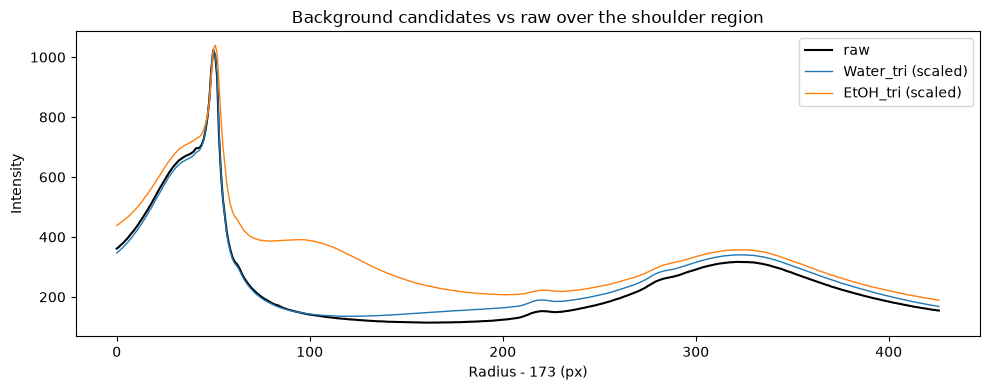

CONFIRMED (Gly_AS_tri, Day 1/2 data): secondary FEP feature present
in BOTH Water_tri and EtOH_tri — shared FEP polymer scattering, not
a Water_tri-specific artefact.


In [15]:
# Diagnostic 5 — is the secondary feature present in BOTH background
# candidates (shared FEP polymer scattering) or specific to Water_tri?
etoh_radial_sum = np.bincount(r_map_full[valid_mask].ravel(), weights=backgrounds["EtOH_tri"][valid_mask].ravel(),
                               minlength=int(r_map_full.max()) + 1)
etoh_radial_cnt = np.bincount(r_map_full[valid_mask].ravel(), minlength=int(r_map_full.max()) + 1)
with np.errstate(invalid="ignore", divide="ignore"):
    etoh_radial_mean = np.where(etoh_radial_cnt > 0, etoh_radial_sum / etoh_radial_cnt, 0.0)

water_level = raw_radial_mean[FEP_RING_R] / bg_radial_mean[FEP_RING_R]
etoh_level = raw_radial_mean[FEP_RING_R] / etoh_radial_mean[FEP_RING_R]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_radial_mean[lo:hi], label="raw", lw=1.5, color="black")
ax.plot(bg_radial_mean[lo:hi] * water_level, label="Water_tri (scaled)", lw=1)
ax.plot(etoh_radial_mean[lo:hi] * etoh_level, label="EtOH_tri (scaled)", lw=1)
ax.set_xlabel(f"Radius - {lo} (px)")
ax.set_ylabel("Intensity")
ax.set_title("Background candidates vs raw over the shoulder region")
ax.legend()
plt.tight_layout()
plt.show()

print("CONFIRMED (Gly_AS_tri, Day 1/2 data): secondary FEP feature present")
print("in BOTH Water_tri and EtOH_tri — shared FEP polymer scattering, not")
print("a Water_tri-specific artefact.")

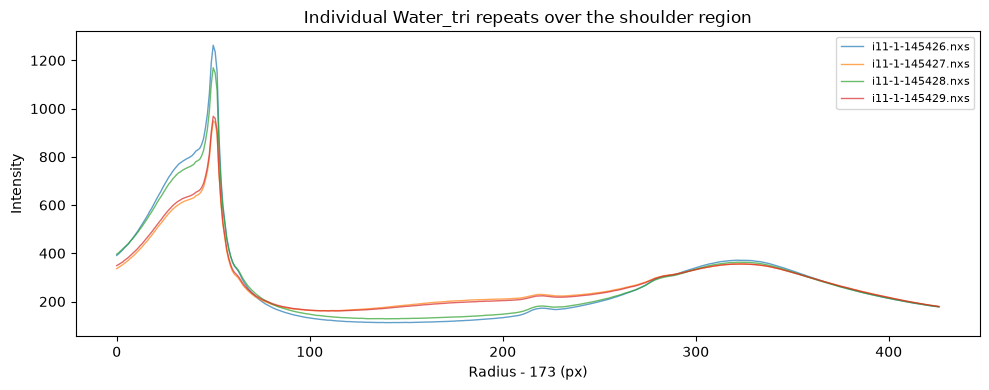

In [16]:
# Diagnostic 6 — consistency across individual Water_tri repeats, to rule
# out one anomalous frame dominating the averaged background.
fig, ax = plt.subplots(figsize=(10, 4))
for fp in BACKGROUND_FILES["Water_tri"]:
    frame = _load_pixium_frame(fp)
    if frame.ndim == 3:
        frame = frame.mean(axis=0)
    s = np.bincount(r_map_full[valid_mask].ravel(), weights=frame[valid_mask].ravel(),
                     minlength=int(r_map_full.max()) + 1)
    c = np.bincount(r_map_full[valid_mask].ravel(), minlength=int(r_map_full.max()) + 1)
    with np.errstate(invalid="ignore", divide="ignore"):
        rm = np.where(c > 0, s / c, 0.0)
    ax.plot(rm[lo:hi], lw=1, alpha=0.7, label=os.path.basename(fp))
ax.set_xlabel(f"Radius - {lo} (px)")
ax.set_ylabel("Intensity")
ax.set_title("Individual Water_tri repeats over the shoulder region")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Attempt 1 (superseded) — scale-deviation trough width

Kept for the record. `trough_r_min`/`trough_r_max` from this cell are
overwritten by Attempt 2 below — do not rely on these values.

In [17]:
# ATTEMPT 1 (superseded — see markdown above and Step 5c conclusion).
# Kept for the record: this measures a real effect (background mismatch)
# but at the wrong radius/width, as shown by the occupancy diagnostic below.
radii_arr = np.array(radii)
scales_arr = np.array(scales)

reference_mask = radii_arr > 1000
baseline_scale = np.median(scales_arr[reference_mask])
baseline_spread = _mad_sigma(scales_arr[reference_mask])

search_region = radii_arr > (FEP_RING_R + 40)
r_search = radii_arr[search_region]
s_search = scales_arr[search_region]
deviation_sigma = 5.0
is_trough = np.abs(s_search - baseline_scale) > deviation_sigma * baseline_spread

if is_trough.any():
    attempt1_r_min = float(r_search[is_trough].min()) - 10
    attempt1_r_max = float(r_search[is_trough].max()) + 10
else:
    attempt1_r_min = attempt1_r_max = None

print(f"Baseline scale (r>1000px): {baseline_scale:.4f} ± {baseline_spread:.4f} (MAD-sigma)")
if attempt1_r_min is not None:
    print(f"Attempt 1 trough: r={attempt1_r_min:.0f}–{attempt1_r_max:.0f}px "
          f"(width={attempt1_r_max-attempt1_r_min:.0f}px) — SUPERSEDED, see Attempt 2")

Baseline scale (r>1000px): 0.8099 ± 0.0096 (MAD-sigma)
Attempt 1 trough: r=330–710px (width=380px) — SUPERSEDED, see Attempt 2


### Attempt 2 (adopted) — empirical annulus occupancy, pooled across frames

In [20]:
# Pool spot_mask_raw radii across ALL confirmed crystal frames (more
# robust than one frame), then measure what fraction of each radial
# annulus is flagged as "spot" at the standard 5σ threshold. A genuinely
# sparse Bragg spot population occupies a tiny fraction of any annulus; a
# systematic subtraction residual occupies a much larger fraction.
all_spot_radii = []
for cf in crystal_frames:
    cf_raw = _load_pixium_frame(cf.filepath, cf.frame_index)
    if cf_raw.ndim == 3:
        cf_raw = cf_raw[cf.frame_index]
    cf_corrected, _ = radial_bestfit_correct(cf_raw, winning_bg_array, valid_mask, r_map_full)
    cf_corrected_clipped = np.clip(cf_corrected, 0.0, None)
    cf_noise_sigma = _mad_sigma(cf_corrected[diffuse_mask])
    cf_spot_mask_raw = (cf_corrected_clipped > SPOT_SIGMA_MULTIPLIER * cf_noise_sigma) & valid_mask
    all_spot_radii.append(r_map_full[cf_spot_mask_raw])
all_spot_radii = np.concatenate(all_spot_radii)

r_max_search = 800
bin_edges = np.arange(0, r_max_search + 5, 5)
counts, _ = np.histogram(all_spot_radii, bins=bin_edges)
annulus_pixel_area = np.array([
    int(((r_map_full >= lo) & (r_map_full < hi) & valid_mask).sum())
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:])
])
with np.errstate(invalid="ignore", divide="ignore"):
    spot_fraction = np.where(annulus_pixel_area > 0, counts / annulus_pixel_area, 0.0)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

OCCUPANCY_THRESHOLD = 0.02   # 2% of an annulus flagged = systematic, not sparse spots
is_ring_residual = spot_fraction > OCCUPANCY_THRESHOLD

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bin_centres, spot_fraction, lw=1)
ax.axhline(OCCUPANCY_THRESHOLD, color="red", ls="--", lw=1, label=f"occupancy threshold ({OCCUPANCY_THRESHOLD:.0%})")
ax.set_xlabel("Radius (px)")
ax.set_ylabel("Fraction of annulus flagged as spot")
ax.set_title("Annulus occupancy — pooled across all confirmed crystal frames")
ax.set_xlim(0, 500)
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'SPOT_SIGMA_MULTIPLIER' is not defined

Take the *contiguous* flagged region anchored at `FEP_RING_R` (not a blind
min/max over every flagged bin — that picked up an unrelated isolated bin
near the beam centre the first time this was tried).

In [19]:
from scipy import ndimage as ndi

labeled, n_labels = ndi.label(is_ring_residual)
ring_bin_idx = np.argmin(np.abs(bin_centres - FEP_RING_R))
ring_label = labeled[ring_bin_idx]

if ring_label == 0:
    raise RuntimeError(
        f"No flagged annulus overlaps FEP_RING_R={FEP_RING_R}px — "
        "check OCCUPANCY_THRESHOLD or inspect the occupancy plot again."
    )

GAP_MERGE_PX = 30
core_mask = labeled == ring_label
core_radii = bin_centres[core_mask]
band_lo, band_hi = core_radii.min(), core_radii.max()

merged_labels = {ring_label}   # track what's already folded in -- avoids infinite loop
changed = True
while changed:
    changed = False
    for lbl in range(1, n_labels + 1):
        if lbl in merged_labels:
            continue
        lbl_radii = bin_centres[labeled == lbl]
        lbl_lo, lbl_hi = lbl_radii.min(), lbl_radii.max()
        if lbl_lo <= band_hi + GAP_MERGE_PX and lbl_hi >= band_lo - GAP_MERGE_PX:
            band_lo, band_hi = min(band_lo, lbl_lo), max(band_hi, lbl_hi)
            merged_labels.add(lbl)
            changed = True

trough_r_min = float(band_lo) - 5
trough_r_max = float(band_hi) + 5
print(f"Ring-anchored FEP exclusion: r={trough_r_min:.0f}–{trough_r_max:.0f}px")

# Standalone exclusion band for spot counting/display (Step 6) — covers
# the full ring+shoulder footprint on its own, independent of ring_mask
# (which continues to be used only for the bias_check QC statistic).
known_fep_exclusion = (r_map_full >= trough_r_min) & (r_map_full <= trough_r_max) & valid_mask
print(f"Known FEP exclusion band: {int(known_fep_exclusion.sum())} px "
      f"({100*known_fep_exclusion.sum()/valid_mask.sum():.2f}% of valid detector)")

NameError: name 'is_ring_residual' is not defined

---
## Step 6 — Production batch: radially-binned subtraction + automated QC

Applies the winning background to every confirmed crystal frame using radially-binned scaling, then runs automated QC (diffuse bias, ring bias) on the RESULT — no manual per-frame inspection required. Frames failing either check are flagged REVIEW, not silently included.

In [ ]:
from pathlib import Path
from fep_subtraction_2d_i11 import _write_corrected_nexus
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from scipy import ndimage

BIAS_THRESHOLD = 1.0
SPOT_SIGMA_MULTIPLIER = 5.0   # consistent with classifier's default sigma_multiplier

# ── Display-only controls for panel c) ─────────────────────────
# These affect ONLY how spots are rendered in the PNG. They do not touch
# spot_pixel_count/spot_density_final (still computed from the unmodified
# spot_mask below) or the NeXus output.
SPOT_DISPLAY_MODE = "binary"   # "binary" = uniform brightness per detected pixel
                                # "intensity" = percentile-scaled grayscale
SPOT_DILATION_PX = 2           # grow each detected pixel by N px so single hits
                                # are visible at full-frame display scale; 0 = off

production_results = []
prod_dir = os.path.join(OUTPUT_DIR, "production")
os.makedirs(prod_dir, exist_ok=True)

for m in crystal_frames:
    fp = m.filepath
    raw = _load_pixium_frame(fp, m.frame_index)
    if raw.ndim == 3:
        raw = raw[m.frame_index]

    corrected, bin_scales = radial_bestfit_correct(raw, winning_bg_array, valid_mask, r_map_full)
    corrected_clipped = np.clip(corrected, 0.0, None)

    diffuse_bias = bias_check(corrected, diffuse_mask)
    ring_bias = bias_check(corrected, ring_mask)
    flags = []
    if abs(diffuse_bias) > BIAS_THRESHOLD:
        flags.append(f"diffuse_bias({diffuse_bias:.2f})")
    if abs(ring_bias) > BIAS_THRESHOLD:
        flags.append(f"ring_bias({ring_bias:.2f})")
    verdict = "PASS" if not flags else "REVIEW"

    stem = os.path.splitext(os.path.basename(fp))[0]

    # ── Spot detection ───────────────────────────────────────
    # Threshold on the diffuse-region noise floor (same MAD-sigma basis as
    # bias_check / the classifier), not a global/visual guess. Pixels in the
    # known FEP exclusion band (main ring + secondary polymer feature, Step
    # 5c) are tracked separately, not silently dropped — they reflect a
    # documented background limitation, not absence of signal there.
    noise_sigma_diffuse = _mad_sigma(corrected[diffuse_mask])
    spot_display_threshold = SPOT_SIGMA_MULTIPLIER * noise_sigma_diffuse
    spot_mask_raw = (corrected_clipped > spot_display_threshold) & valid_mask
    spot_mask = spot_mask_raw & ~known_fep_exclusion          # reportable candidate diffraction
    n_excluded_as_known_fep = int((spot_mask_raw & known_fep_exclusion).sum())

    spot_pixel_count = int(spot_mask.sum())
    spot_density_final = spot_pixel_count / int(valid_mask.sum())

    # ── Spot rendering (display only) ────────────────────────
    display_mask = spot_mask
    if SPOT_DILATION_PX > 0:
        display_mask = ndimage.binary_dilation(spot_mask, iterations=SPOT_DILATION_PX)
        display_mask &= valid_mask   # never grow spots into masked regions

    if SPOT_DISPLAY_MODE == "binary":
        spots_display = np.where(display_mask, 1.0, 0.0)
        spots_vmin, spots_vmax = 0.0, 1.0
    else:  # "intensity"
        spots_display = np.where(display_mask, corrected_clipped, 0.0)
        spot_vals = spots_display[spots_display > 0]
        spots_vmin = 0.0
        spots_vmax = float(np.percentile(spot_vals, 99.5)) if spot_vals.size > 0 else 1.0

    # Output 1: corrected frame as NeXus — unchanged, this is what feeds
    # baselining/integration/diffraction sorting downstream
    nxs_out_path = os.path.join(prod_dir, f"{stem}_corrected.nxs")
    _write_corrected_nexus(
        corrected=corrected_clipped,
        source_filepath=Path(fp),
        output_filepath=Path(nxs_out_path),
        output_detector_path="entry1/pixium_hdf/data",
        scale_factor=1.0,   # radially-binned: no single scale value applies; per-bin scales in bin_scales if needed
        background_type=WINNING_BACKGROUND,
        n_background_frames=len(BACKGROUND_FILES[WINNING_BACKGROUND]),
        clip_negative=True,
    )

    # Output 2: visual PNG — raw | corrected | spots-only, for QC inspection
    png_out_path = os.path.join(prod_dir, f"{stem}_comparison.png")
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    vmin = max(1, np.percentile(raw[raw > 0], 1))
    axes[0].imshow(raw, origin="lower", norm=LogNorm(vmin=vmin, vmax=raw.max()), cmap="viridis")
    axes[0].set_title(f"a) Raw — {os.path.basename(fp)}")

    vmin_c = max(0.1, np.percentile(corrected_clipped[corrected_clipped > 0], 1)) if (corrected_clipped > 0).any() else 0.1
    axes[1].imshow(corrected_clipped, origin="lower", norm=LogNorm(vmin=vmin_c, vmax=max(corrected_clipped.max(), 1)), cmap="viridis")
    axes[1].set_title(f"b) Corrected ({WINNING_BACKGROUND}) — {verdict}")

    axes[2].imshow(spots_display, origin="lower", cmap="gray", vmin=spots_vmin, vmax=spots_vmax)
    axes[2].set_facecolor("black")
    axes[2].set_title(f"c) Spots only (>{SPOT_SIGMA_MULTIPLIER:.0f}\u03c3, n={spot_pixel_count}, "
                       f"{n_excluded_as_known_fep} excluded as known FEP, dilated {SPOT_DILATION_PX}px)")

    plt.tight_layout()
    plt.savefig(png_out_path, dpi=150)
    plt.close(fig)

    production_results.append({
        "file": os.path.basename(fp), "background": WINNING_BACKGROUND,
        "diffuse_bias": diffuse_bias, "ring_bias": ring_bias,
        "spot_pixel_count": spot_pixel_count, "spot_density_final": spot_density_final,
        "n_excluded_as_known_fep": n_excluded_as_known_fep,
        "verdict": verdict, "flags": "; ".join(flags),
        "nexus_output": nxs_out_path, "png_output": png_out_path,
    })
    print(f"  {os.path.basename(fp)}: {verdict}  spots={spot_pixel_count}  "
          f"(excl_fep={n_excluded_as_known_fep})" + (f" [{'; '.join(flags)}]" if flags else ""))

df_production = pd.DataFrame(production_results)
df_production.to_csv(os.path.join(OUTPUT_DIR, "production_run_summary.csv"), index=False)

n_pass = (df_production["verdict"] == "PASS").sum()
print(f"\n✅ Production pass complete: {len(df_production)} frames, {n_pass} PASS, {len(df_production)-n_pass} REVIEW")
print(df_production[["file", "diffuse_bias", "ring_bias", "spot_pixel_count", "n_excluded_as_known_fep", "verdict"]].to_string(index=False))

---
## Step 7 — Summary

In [ ]:
print("=" * 60)
print("  PRODUCTION RUN SUMMARY")
print("=" * 60)
print(f"  Crystal system    : {CRYSTAL_SAMPLE_CODE}")
print(f"  Distance/technique: {DISTANCE_MM}mm / {EXPOSURE_CODE}")
print(f"  Background used   : {WINNING_BACKGROUND}")
print(f"  Correction method : radially-binned best-fit scale")
print(f"  Frames processed  : {len(df_production)}")
print(f"  PASS / REVIEW     : {n_pass} / {len(df_production)-n_pass}")
print(f"  Mask used         : {MASK_PATH_FINAL}")
print(f"  Known FEP exclusion band (Step 5c): r={fep_secondary_r}±20px + ring_mask, "
      f"{int(known_fep_exclusion.sum())} px ({100*known_fep_exclusion.sum()/valid_mask.sum():.2f}% of valid detector)")
print(f"  Mean spots excluded as known FEP  : {df_production['n_excluded_as_known_fep'].mean():.0f} px/frame")
print(f"  Output directory  : {prod_dir}")
print(f"  Summary CSV       : {os.path.join(OUTPUT_DIR, 'production_run_summary.csv')}")

if (df_production['verdict'] == 'REVIEW').any():
    print("\n⚠️  REVIEW frames — check individually before treating as final:")
    for _, row in df_production[df_production['verdict']=='REVIEW'].iterrows():
        print(f"    {row['file']}: {row['flags']}")